# LAB1: Preprocessing danych
Zapoznaj się z treścią niniejszego notatnika czytając i wykonując go komórka po komórce. Wykonaj napotkane zadania/ćwiczenia.

In [19]:
# --- Import potrzebnych bibliotek ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Konfiguracja wykresów
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

survived	Informacja, czy pasażer przeżył (0 = nie, 1 = tak).

pclass	Klasa biletu (1 = pierwsza, 2 = druga, 3 = trzecia).

sex	Płeć pasażera (male, female).

age	Wiek pasażera (lata, liczba zmiennoprzecinkowa).

sibsp	Liczba rodzeństwa i/lub małżonków podróżujących razem.

parch	Liczba rodziców i/lub dzieci podróżujących razem.

fare	Cena biletu (opłata).

embarked	Kod portu zaokrętowania (C, Q, S).

class	Klasa biletu w formie tekstowej (First, Second, Third).

who	Typ osoby (man, woman, child).

adult_male	Czy pasażer był dorosłym mężczyzną (True/False).

deck	Pokład pasażera (A–G, często brak danych).

embark_town	Pełna nazwa portu zaokrętowania (Cherbourg, Queenstown,
Southampton).

alive	Informacja o przeżyciu w formie tekstowej (yes/no).

alone	Czy pasażer podróżował sam (True/False).

In [20]:
# =============================================
# 1. Wczytanie danych
# =============================================
df = sns.load_dataset("titanic")

print("Pierwsze 5 wierszy:")
display(df.head(30))

print("\nInformacje o danych:")
print(df.info())

print("\nStatystyki opisowe:")
display(df.describe(include="all"))

Pierwsze 5 wierszy:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False



Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Statystyki opisowe:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pierwszym krokiem analizy danych powinno być wizualne zapoznanie się ze zbiorem. Oczywiście w przypadku dużych zbiorów taka analiza jest niemożliwa ale pierwsze spojrzenie może dać pewną orientację na temat typów danych, układu kolumn itd. W kolejnej  komórce wykonaj taką prostą analizę używając funkcji według własnego pomysłu ( np pierwsze kolumny, ,typy danych w kolumnach, statystyki opisowe itp.)

Czy wszystkie kolumny są potrzebne? ( czy stnieją kolumny od siebie zależne?)

In [21]:
# =============================================
#  Wstępna analiza (orientacja)
# =============================================
#TODO

In [22]:
# =============================================
# Usuń duplikaty rekordów Jeżeli występują
# =============================================

#TODO

df = df.drop_duplicates().copy()
print(df.shape)

(784, 15)


In [23]:
# =============================================
# Obsługa braków danych
# =============================================
print("\nLiczba braków danych:")
print(df.isnull().sum())

# W procesie uzupełniania danych wybierz metody: mediana dla numerycznych, moda dla kategorycznych

#co sądzisz o zmiennej Age ? Sugestia: dużo braków — uzupełnić medianą/średnią ; rozważyć binowanie (dziecko/dorosły)


#TODO

#co sądzisz o zmiennej deck? Czy mozna ją po prostu zignorować ?

# średnie wieku w zależności od grupy "who"
srednie = df.groupby("who")["age"].median()

embarked_mod = df["embarked"].mode()[0]

embarked_town_mod = df["embark_town"].mode()[0]


# uzupełnianie braków w df
df.loc[df["age"].isna(), "age"] = (
    df.loc[df["age"].isna(), "who"].map(srednie)
)

df.loc[df["embarked"].isna(), "embarked"] = embarked_mod

df.loc[df["embark_town"].isna(), "embark_town"] = embarked_town_mod

print(df[["who", "age"]].head(20))
print(df.isnull().sum())


Liczba braków danych:
survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64
      who   age
0     man  22.0
1   woman  38.0
2   woman  26.0
3   woman  35.0
4     man  35.0
5     man  31.0
6     man  54.0
7   child   2.0
8   woman  27.0
9   child  14.0
10  child   4.0
11  woman  58.0
12    man  20.0
13    man  39.0
14  child  14.0
15  woman  55.0
16  child   2.0
17    man  31.0
18  woman  31.0
19  woman  30.0
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           582
embark_town      0
alive            0
alone            0
dtype: int64


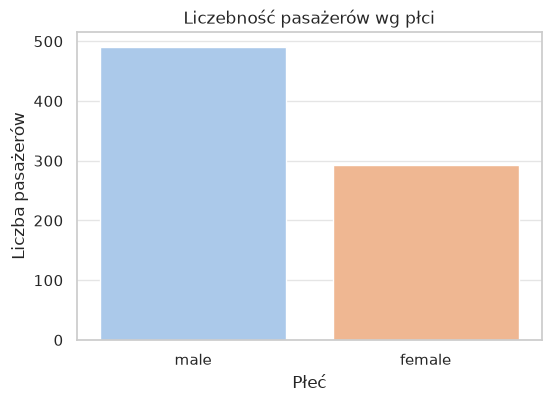

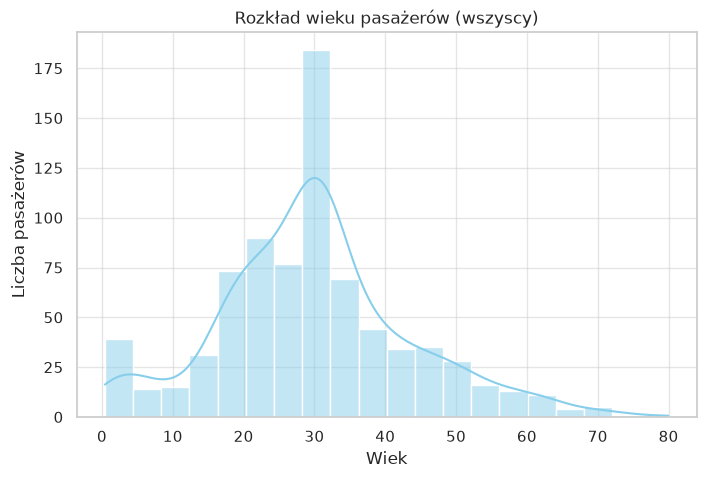

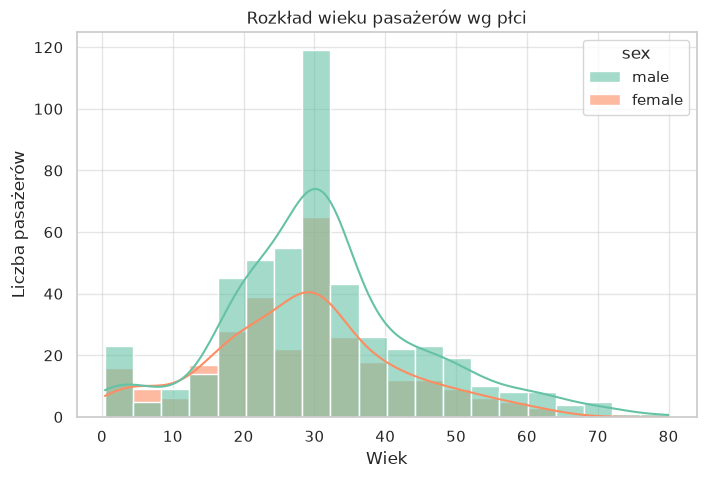

In [24]:
# =============================================
# Analiza częstości
# =============================================

#Przygotuj w formie wykresów analizę kolumny 'sex'.
# Przygotuj w formie histogramów analizy kolumny 'age' w całości oraz z podziałem na płeć.
#Krok histogramu (bind) dobierz według własnego uznania tak aby wykres był w miarę czytelny

#TODO

# --- 1. Analiza kolumny 'sex' ---
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="sex", palette="pastel", legend=False)
plt.title("Liczebność pasażerów wg płci")
plt.xlabel("Płeć")
plt.ylabel("Liczba pasażerów")
plt.show()

# --- 2. Histogram wieku (całość) ---
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", bins=20, kde=True, color="skyblue")
plt.title("Rozkład wieku pasażerów (wszyscy)")
plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.show()

# --- 3. Histogram wieku z podziałem na płeć ---
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", bins=20, hue="sex", kde=True, palette="Set2", alpha=0.6)
plt.title("Rozkład wieku pasażerów wg płci")
plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.show()

## Transformacje danych

In [25]:

print("Kształt danych :", df.shape)

Kształt danych : (784, 15)



##Wstępna transformacja danych

In [26]:


# =============================================
# --- Skalowanie kolumn numerycznych ---
# =============================================

print("\nKształt danych przed kodowaniem:", df.shape)

#TODO
# wybór kolumn numerycznych
num_cols = df.select_dtypes(include="number").columns
print(num_cols)

# standaryzacja (średnia=0, std=1)
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])


Kształt danych przed kodowaniem: (784, 15)
Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


In [27]:
# =============================================
# --- One-hot encoding ---
# =============================================
#Dla zmiennych kategorycznych takich jak embarked Zastosuj metodę kodowania One-Hot encoding.
#Zastanów się dlaczego kodowanie zmiennych kategorycznych za pomocą liczb naturalnych
#na przykład zamiast A B C zastosowanie 1 2 3 może być złym pomysłem.
#Dla zmiennych kategorycznych dokładnie Przeanalizuj liczebność zbioru danych.
#W rzeczywistych danych często zdarzają się pomyłki typu Cherbourg --> Cherburg

cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns

#pomijanie deck
cat_cols = [col for col in cat_cols if col != "deck"]

df_encoded = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols)


print("\nKształt danych przed kodowaniem:", df_encoded.shape)





Kształt danych przed kodowaniem: (784, 25)


In [28]:
# =============================================
# Podsumowanie
# =============================================
print("""
PODSUMOWANIE:
- Uzupełniono braki danych (mediana dla numerycznych, moda dla kategorycznych).
- Usunięto duplikaty.
- Ujednolicono tekstowe wartości (np. 'embarked').
- Przeanalizowano rozkłady (płeć, wiek).
- Wykonano skalowanie zmiennych numerycznych i zakodowano zmienne kategoryczne.
Preprocessing jest kluczowy, ponieważ dane surowe często zawierają braki, duplikaty
i niespójności – oczyszczone dane pozwalają na lepsze działanie algorytmów ML.
""")



PODSUMOWANIE:
- Uzupełniono braki danych (mediana dla numerycznych, moda dla kategorycznych).
- Usunięto duplikaty.
- Ujednolicono tekstowe wartości (np. 'embarked').
- Przeanalizowano rozkłady (płeć, wiek).
- Wykonano skalowanie zmiennych numerycznych i zakodowano zmienne kategoryczne.
Preprocessing jest kluczowy, ponieważ dane surowe często zawierają braki, duplikaty
i niespójności – oczyszczone dane pozwalają na lepsze działanie algorytmów ML.

